# Solphin Full Workflow

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials.

Calculating the Photovoltaic figure of merit requires various data characterising a material's optoelectronic properties. Solphin provides methods to automate/assist calculating these properties using VASP (the Vienna Ab-initio Simulation Package).

In [1]:
#import the required modules

import solphin.db_fom as db_fom
import solphin.db_plots as db_plotting
import solphin.final_results as final_results
import solphin.vasp_inputs as vasp_inputs
import solphin.optics as optics
import solphin.band_structure as band_structure
import solphin.spectral as spectral
import solphin.dos as dos
from matplotlib import pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2
%matplotlib inline

## Using Solphin to generate VASP input files



### Global Settings

These settings should apply to all calculations in the workflow, and are the essential first choice of a DFT study. You must choose:

- Appropiate values for the `ENCUT` and `KSPACING` for your system. Convergence testing is the commonly used method of determining the appropiate values, see [here](https://github.com/kavanase/vaspup2.0).

- A functional. It is recommended to use hybrid DFT (HSE06 or PBE0) when investigating PV materials to achieve high-quality publishable results.

In [2]:
functional = 'HSE06'                         # The DFT functional
encut = 450                                  # Plane-wave energy cutoff                
kspacing = 0.2                               # k-point sampling density

### Geometry Optimisation / Relaxation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy arrangement of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, the Materials Project, or experimental studies. Placeholder currently accepts  the VASP POSCAR/CONTCAR, .cif, .xyz, or .json formats.



In [3]:
# Set the structure filename and calculation settings

initial_structure = 'cdte/relaxed_primitive_POSCAR'
relax_directory = 'relax'                               # The folder you want to run the calculation in

In [6]:
# Load the structure
structure = vasp_inputs.read_structure_pmg(initial_structure)

# Generate the calculations
vasp_inputs.write_vasp_calculation(
    structure=structure, 
    recipe=functional, 
    out_dir=relax_directory, 
    patches=['relax_cell', 'tight_relax'], 
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

Once the relaxation calculation is complete, we load the relaxed structure to use as the basis for the rest of our calculations:

In [4]:
# Load the structure
contcar = f'{relax_directory}/CONTCAR'
structure = vasp_inputs.read_structure_pmg(contcar)

### Electronic Density of States and Optical Absorption

* This calculation produces the optoelectronic data we need.

* This time the structure we feed in is the `CONTCAR` generated in the previous step, which contains our "relaxed" or "optimised" structure.

* To get the most accurate results, the shape of the Density of States and optical absorption spectrum should be sufficiently converged with respect to `KSPACING` and `NBANDS`.

In [5]:
#Set the output directory for the optics calculation
optics_directory = 'optics'

In [8]:
# Generate the calculation
vasp_inputs.write_vasp_calculation(
    structure=structure, 
    recipe=functional, 
    out_dir=optics_directory, 
    patches=["optics"], 
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02, "LORBIT": 14})

### Band Structure

The electronic band structure of a material shows the relationship between the different possible electronic states and their distribution in momentum space. This is important for determining the band gap of the system.

- To reduce the three-dimensional momentum space into a single axis, we sample points along a specific high-symmetry path. 
- There are different choices of definition for this path, but all require a "canonical" orientation of the structure with respect to the axes.

In [6]:
#Calcualate the high symmetry path for our structure, and ensure we work with the canonical orientation
canonical_structure, band_path = band_structure.generate_band_structure_path(structure=structure, definition="bradcrack")

Generated high-symmetry path of 179 k-points


- Since all k-points are independent problems, we can split this task into multiple parallel calculations to improve efficiency. This is usually only necessary if using a hybrid functional.

- If using a hybrid functional, we also need to include some additional k-points in each calculation - the same ones we used in our DOS/Optics.

In [12]:
# #GGA functional
band_directory = "band_gga"
functional="PBEsol"
splits = 1
scf_kpoints = None
scf_charge = f"{optics_directory}/CHGCAR"

#Hybrid Functional
# functional="HSE06"
# band_directory = "band_hybrid"
# splits = 5
# scf_kpoints = f"{optics_directory}/IBZKPT"
# scf_charge = None

In [11]:
band_structure.write_band_structure_calculation(
    structure=canonical_structure,
    kpath=band_path,
    band_directory=band_directory,
    functional=functional,
    splits=splits,
    scf_charge=scf_charge,
    scf_kpoints=scf_kpoints,
    user_incar_settings={"ENCUT":encut})

## Analysing the Results of VASP Calculations

### Electronic Density of States/Optics

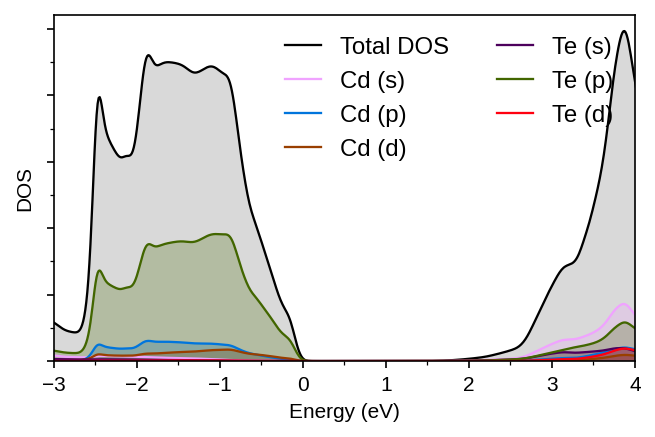

In [6]:
dos.plot_dos(filename=f'{optics_directory}/vasprun.xml', xmin=-3, xmax=4, gaussian=0.05, save=False)

In [7]:
dos.write_eff_mass(
    k0_frac=np.array([0.0, 0.0, 0.0]),
    structure=structure,
    functional="HSE06",
    encut=450,
)

In [8]:
result = dos.compute_dos(
    dos_vasprun="dos_Se_cc/vasprun_5.xml",
    carrier="electrons",
    energy_window=0.1,
)

print(result)

print(
    "Mass passed to FOM:",
    result.final_result,
    "m_e",
)

dos_mass = result.final_result

/home/puc369/miniconda3/envs/toolbox/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1328: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
/home/puc369/miniconda3/envs/toolbox/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1339: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


  Computing electron Crovetto DOS effective mass...
  Computing hole Crovetto DOS effective mass...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  Carrier            : electrons
  Fitted mass        : 0.047220 m_e
  Fit quality        : R² = 0.702790
  DOS points fitted  : 7

  This DOS calculation does not contain enough well-resolved
  near-edge DOS data to determine the Crovetto DOS effective
  mass reliably.

  Consider either:
    1. Re-running the DOS calculation with a denser regular k-point grid.
    2. Supplying an alternative effective-mass estimate if a denser
       hybrid-functional calculation is prohibitively expensive.

  The current fitted mass should therefore be treated as provisional.

  Fitting-window behaviour:

  Crovetto DOS effective-mass convergence (electrons)
 Window / eV     m_DOS / m_e           R²        N
-----------------------------------------------------

### Optical Absorption Spectrum

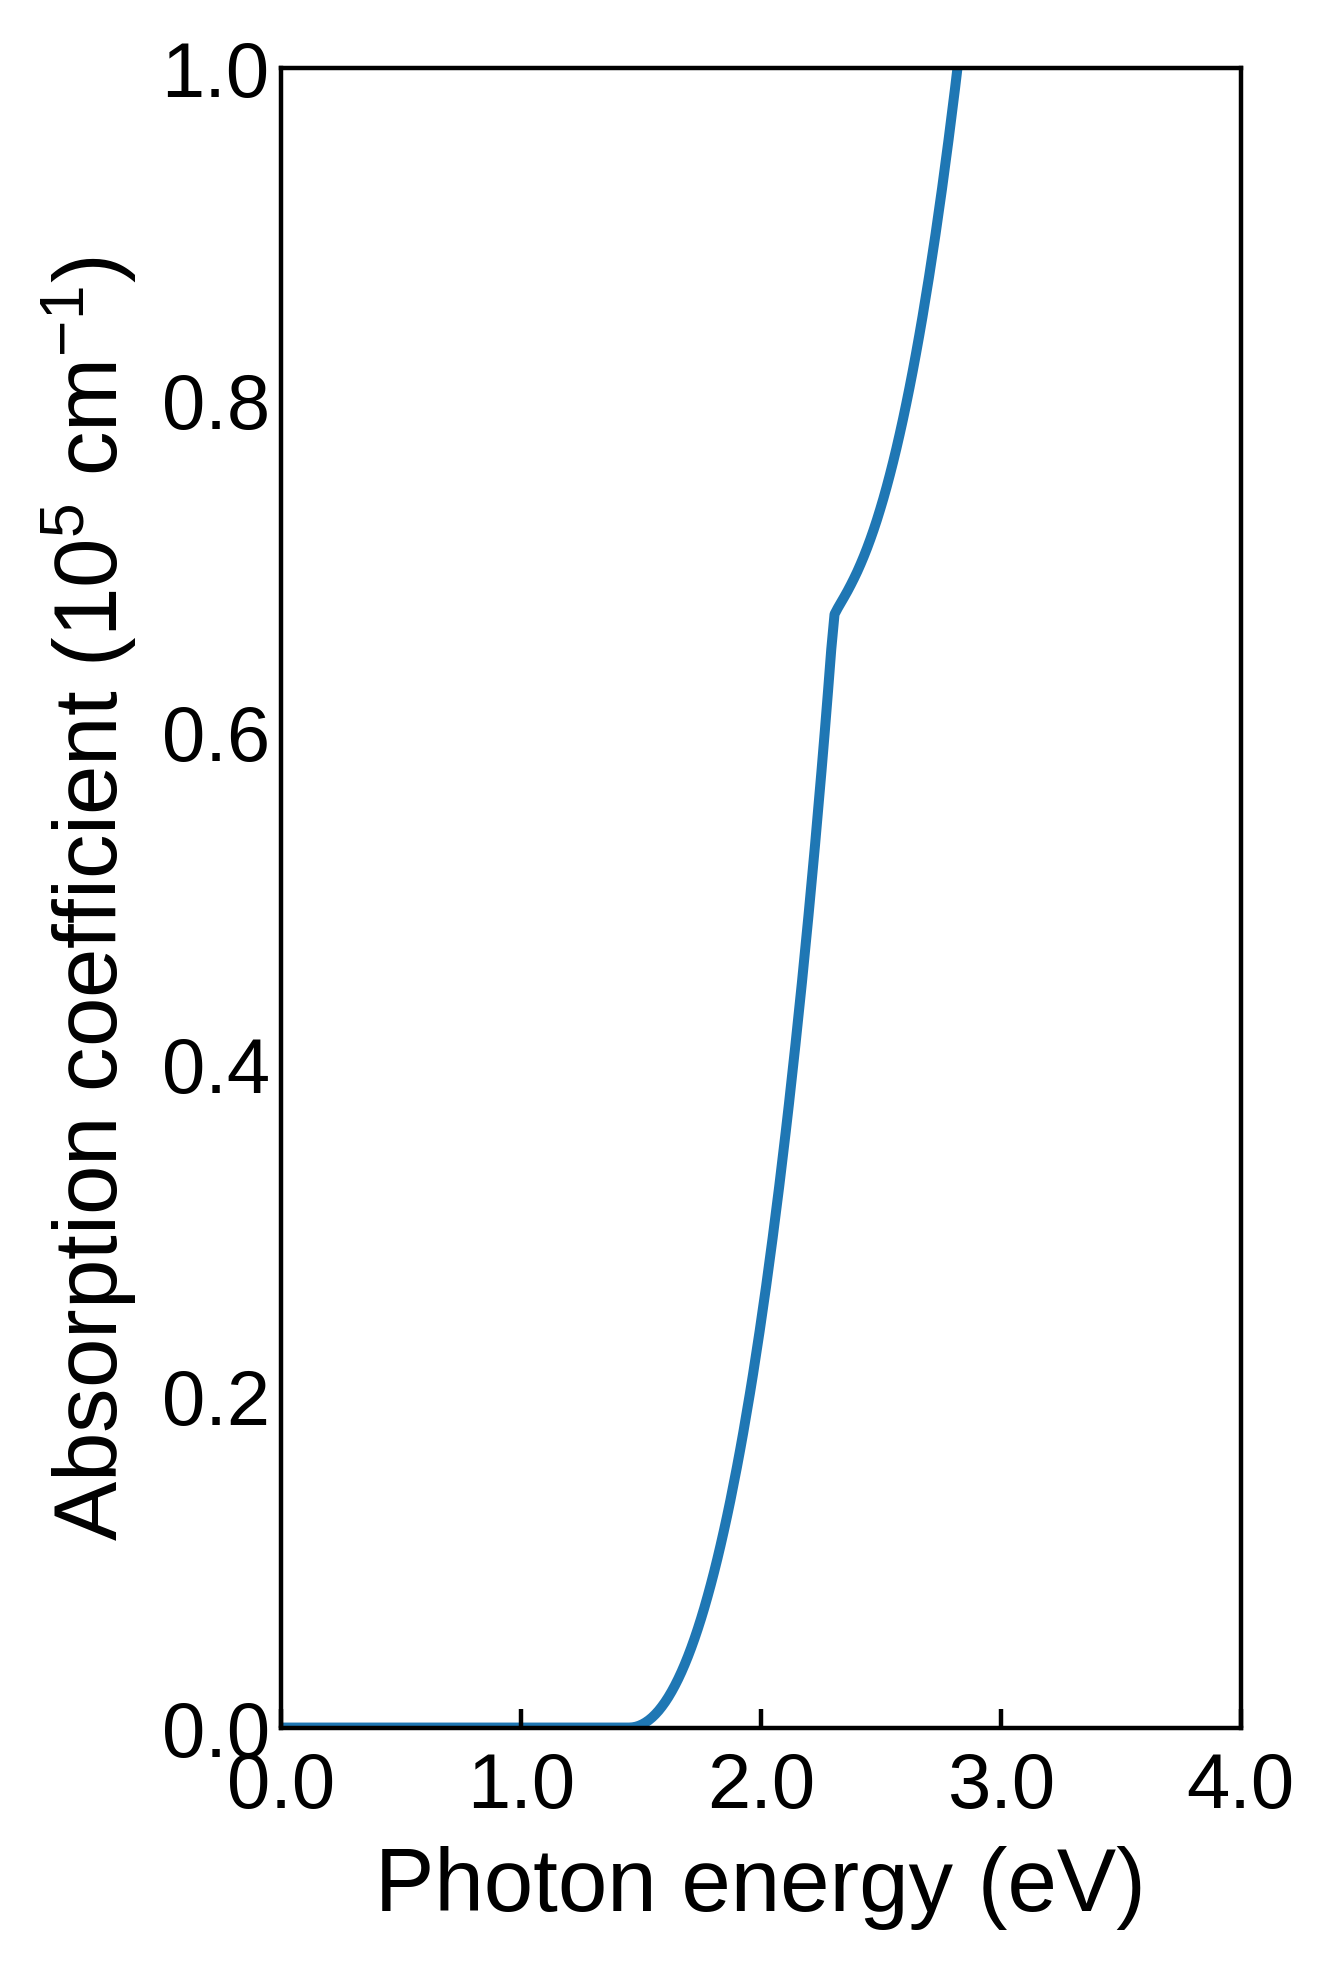

In [9]:
optics.plot_absorption(optics_directory=optics_directory)

##### Optical/High-Frequency/Static Dielectric Constant

In [10]:
eps_inf, eps_inf_tensor, _, _, _ = optics.calc_dielectric(filename=f'{optics_directory}/vasprun.xml')

print("E_∞:", eps_inf)

print("")
print("E_∞ tensor:")
print(eps_inf_tensor)

E_∞: 6.5274

E_∞ tensor:
[[ 6.5274 -0.     -0.    ]
 [-0.      6.5274  0.    ]
 [-0.      0.      6.5274]]


### Band Structure

Band Gap = 0.5486 eV, \Gamma-\Gamma


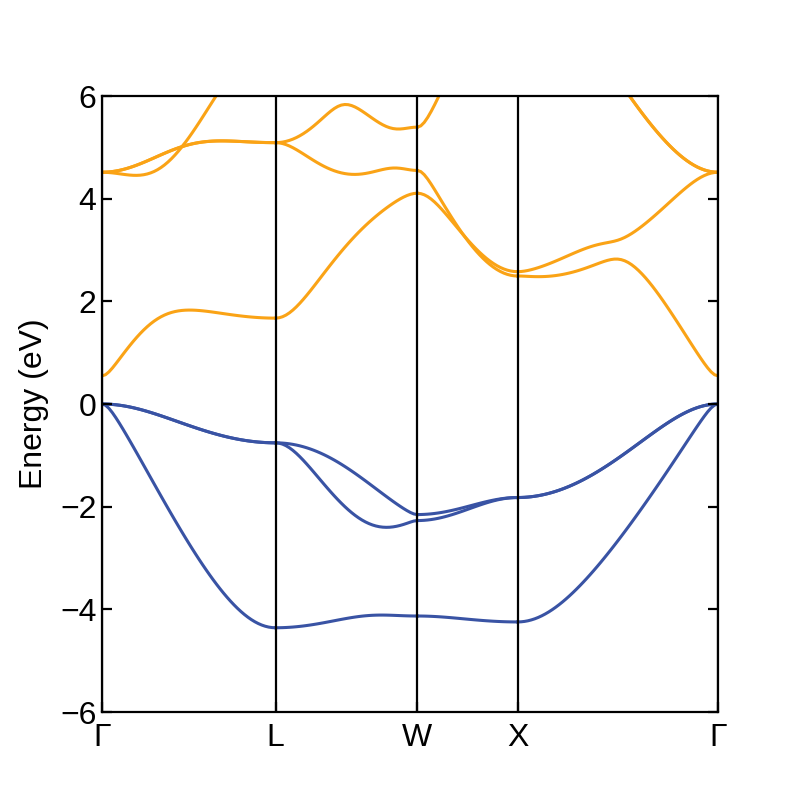

In [25]:
#Extract (and recombine) vaspruns to create a single band structure object
bs = band_structure.get_band_structure(band_directory, splits) 

#Plot the band structure, with the DOS alongside if desired
fig, ax = plt.subplots(figsize=(4,4), dpi=200)
band_structure.plot_band_structure(bs, plt, ymin=-6, ymax=6)

#Extract the band gap for use in the FOM and report it
fundamental_gap = bs.get_band_gap()
E_gap_fundamental = fundamental_gap["energy"]
E_gap_direct = bs.get_direct_band_gap()
print(f"Band Gap = {E_gap_fundamental} eV, {fundamental_gap["transition"]}")

## Calculating the SLME and Blank et al. metrics

In [14]:
spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"
spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)

In [15]:
# Generates a n_real.dat for use in SLME and Blank et al
optics.generate_n_real(optics_directory)

### SLME

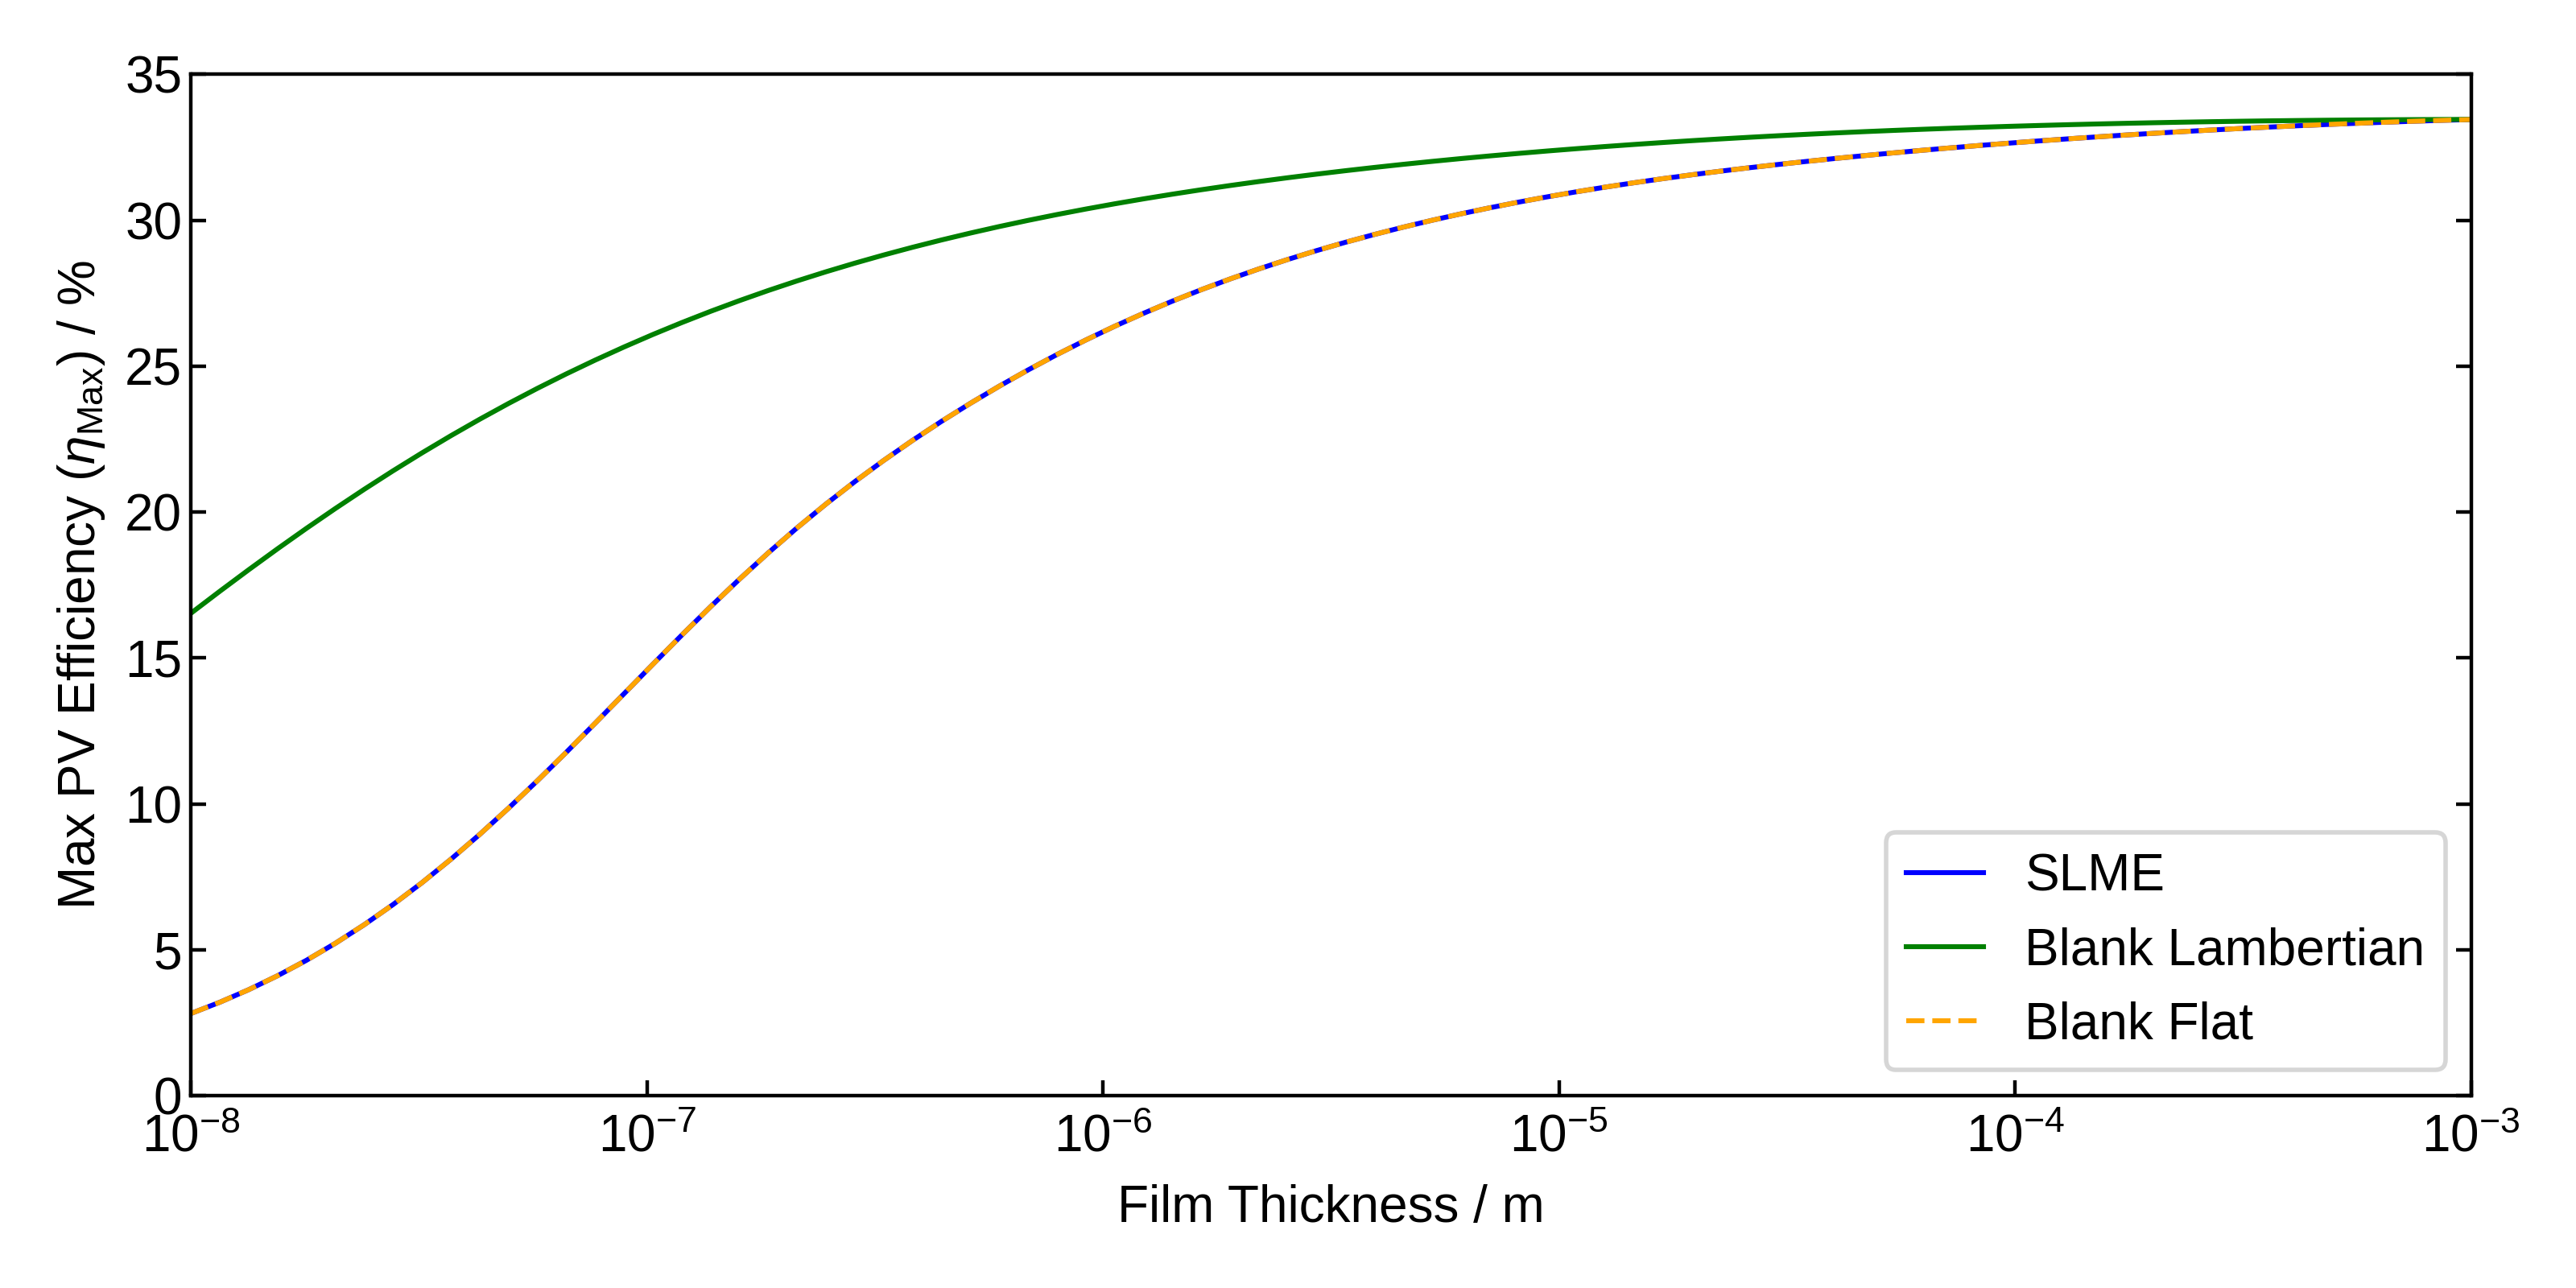

In [24]:
optics.make_blank_plot(optics_directory, direct_gap=1.3, indirect_gap=1.3, spectrum_type="AM1.5", Qi=1.0, n=3.5, thickness_range=None, save=True)

## Obtaining the Detailed Balance and Shockley-Queisser Limit

By supplying a band gap (eV) and operating temperature (K), the Detailed Balance results can be obtained and plotted.

In [17]:
# Define the operating temperature of the cell and Fundamental band gap (?)

Tcell = 300             # Operating Temperature
spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

# Convert the spectrum
spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)

This can also be done interactively:

interactive(children=(FloatSlider(value=1.6, description='Band Gap (eV)', layout=Layout(width='800px'), max=3.…

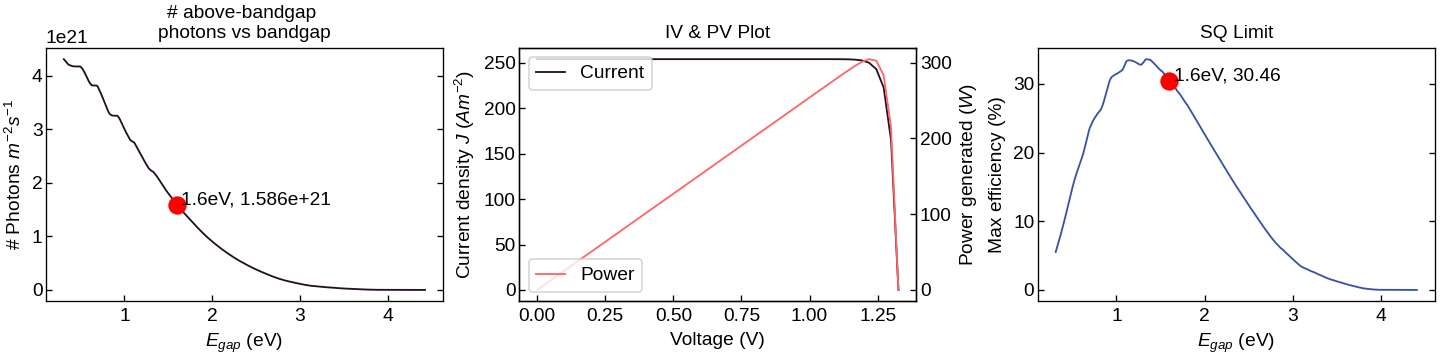

In [26]:
%matplotlib widget
db_plotting.plot_db_combined_interactive()

## Calculating The Photovoltaic Figure of Merit

This section brings together various properties to calculate the Photovoltaic Figure of Merit. Some of these must be manually specified - taken from other sources or representative values. Any of the calculated values from previous sections can be manually overwritten.

In [27]:
# Taken from the previous sections of vscode-remote://ssh-remote%2Bbluebear.bham.ac.uk/rds/homes/p/puc369/scanlodo-pv-defects/Copper_Chalcogenides/Cu2GeS3/Imm2/BAND_SP_GGA_U/job.sh
# E_gap =                 # E₉ Electronic Band gap (eV)
# eps_inf =               # E_∞ Electronic/Optical/Static dielectric constant (unitless)
# spectral_average =      # Spectral average (alpha), (cm⁻¹)
# spectral_dispersion =   # Spectral dispersion (sigma), (unitless)
# dos_mass =              # m density of states effective mass (m₀)
# photon_spectrum =       # Photon spectrum

E_gap = 1.3

spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(optics_directory, spectrum, E_gap=E_gap)

In [28]:
# Must be manually specified

tau = 2.5e-7              # Carrier lifetime (s)
mu = 10                   # Carrier mobility (cm²V⁻¹s⁻¹)
dopant_density = 1e16     # Dopant density (cm⁻³)

In [29]:
#Calculate the FoM using the efficiency metric
sq, fom_sq, eff, FOM = final_results.SQ_relative_FOM_PV_efficiency(E_gap, photon_spectrum, spectral_average, tau, spectral_dispersion, dos_mass, dopant_density, eps_inf, mu, Tcell)
print(f"Photovoltaic Figure of Merit relative to the SQ limit: {fom_sq:.2f} %")
print(f"Photovoltaic Figure of Merit total efficiency: {eff:.2f} %")
print(f"SQ limit: {sq:.2f} %")
print(f"Photovoltaic Figure of Merit: {FOM:.2f}")

Photovoltaic Figure of Merit relative to the SQ limit: 19.99 %
Photovoltaic Figure of Merit total efficiency: 6.61 %
SQ limit: 33.07 %
Photovoltaic Figure of Merit: 1.65


In [22]:
final_results.print_final_result_interactive(E_gap, photon_spectrum, spectral_average, tau, spectral_dispersion, dos_mass, dopant_density, eps_inf, mu, Tcell)

interactive(children=(FloatLogSlider(value=1e+16, description='Dopant Density (cm⁻³)', layout=Layout(width='80…

interactive(children=(FloatLogSlider(value=1e+16, description='Dopant Density (cm⁻³)', layout=Layout(width='80…

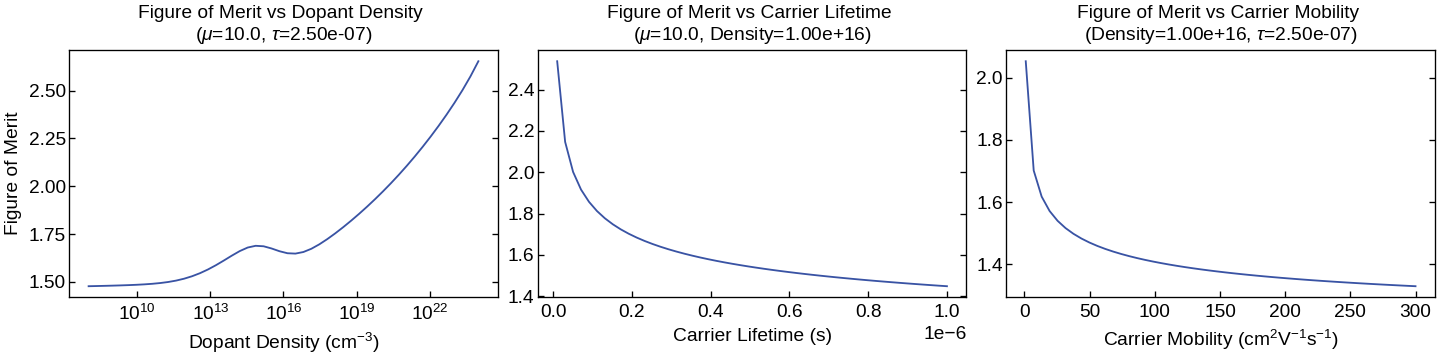

In [23]:
%matplotlib widget
final_results.plot_final_result_interactive(E_gap, photon_spectrum, spectral_average, tau, spectral_dispersion, dos_mass, dopant_density, eps_inf, mu, Tcell)

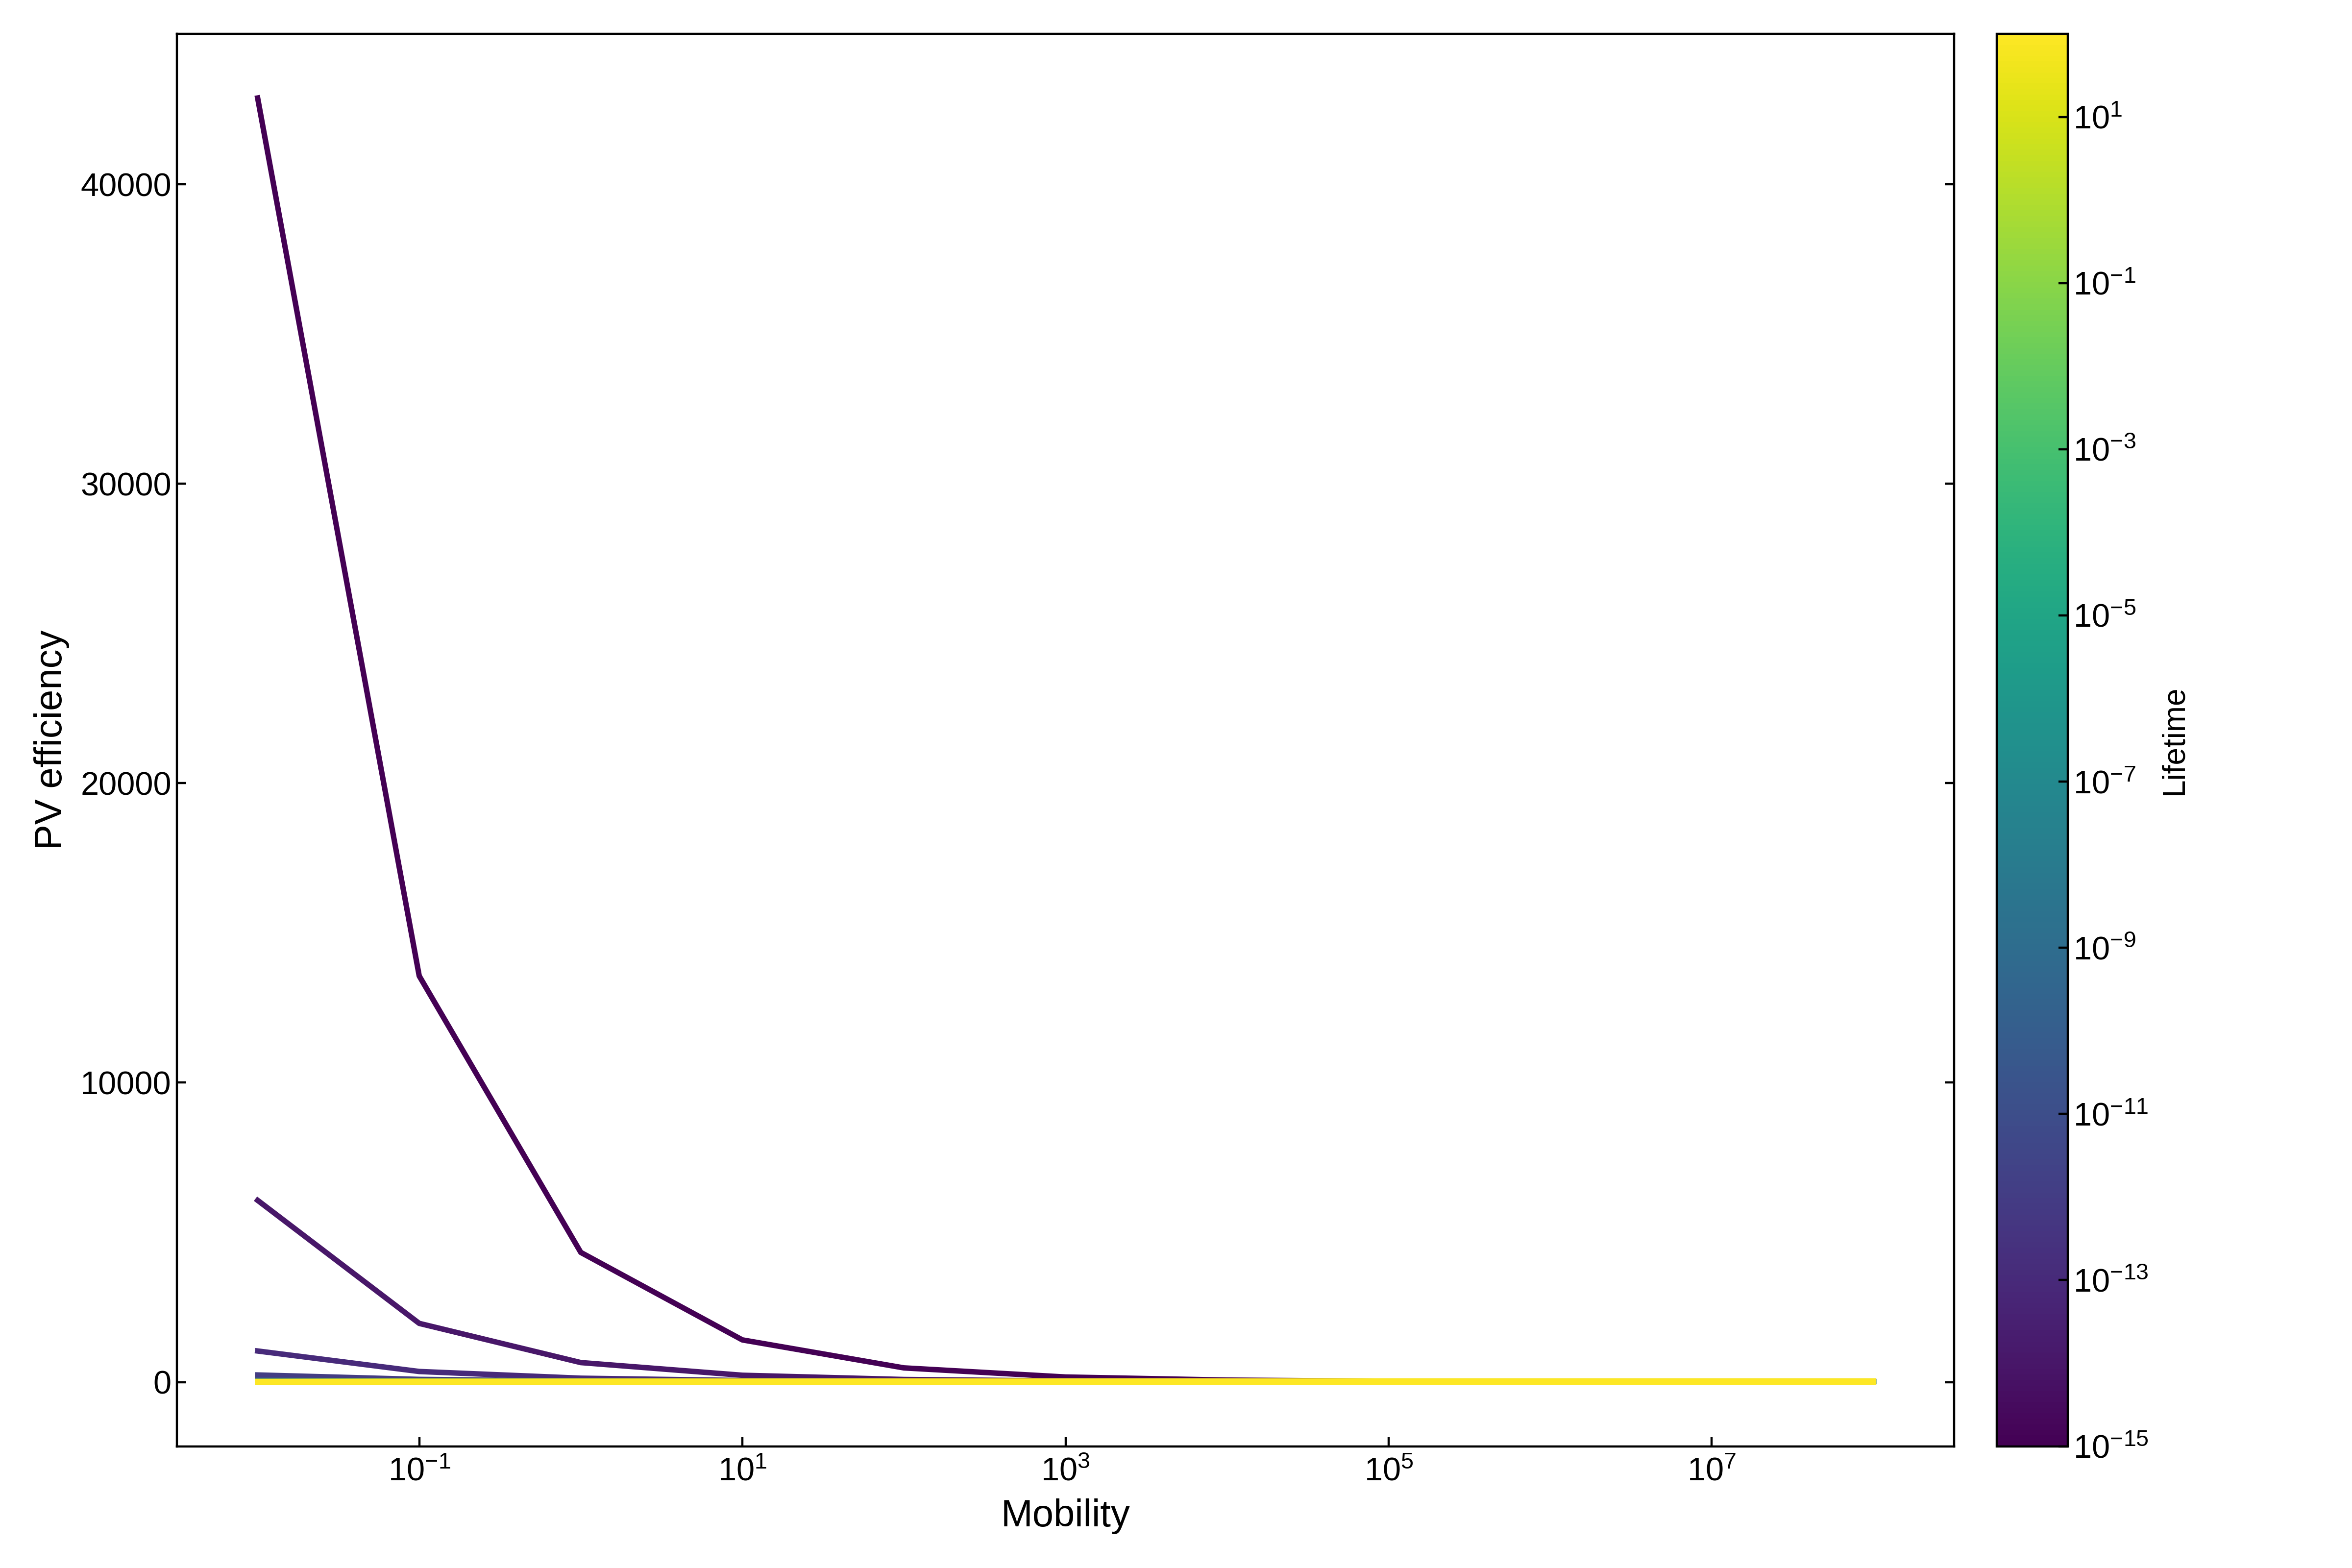

In [38]:
final_results.mobility_plot(
    E_gap,
    photon_spectrum,
    spectral_average,
    spectral_dispersion,
    dos_mass,
    eps_inf,
    dop_density=1e10,
    mob_min=-2,
    mob_max=9,
    lifetime_min=-15,
    lifetime_max=3,
    step=1,
    Tcell=300
)